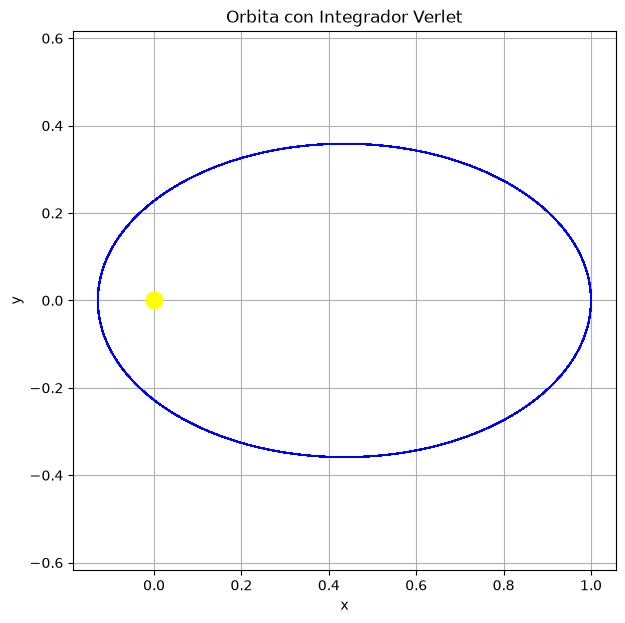

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del problema

G = 4.0 * np.pi**2
M = 1.0

t_0 = 0.0
t_f = 20.0
n = 1000000
h = (t_f - t_0) / n

t = np.linspace(t_0, t_f, n)
Q = np.zeros((n, 4))

# CONDICIONES INICIALES (x, y, vx, vy)


Q[0, 0] = 1.0
Q[0, 1] = 0.0
Q[0, 2] = 0.0
Q[0, 3] = 3.0


# MÉTODO VERLET 
# Aceleracion inicial a t = 0
r2_0 = Q[0, 0]**2 + Q[0, 1]**2
ax0 = -G * M * Q[0, 0] / (r2_0**(3.0 / 2.0))
ay0 = -G * M * Q[0, 1] / (r2_0**(3.0 / 2.0))

S_x = Q[0, 0] - h * Q[0, 2] + 0.5 * ax0 * (h**2)
S_y = Q[0, 1] - h * Q[0, 3] + 0.5 * ay0 * (h**2)

Q[1, 0] = 2.0 * Q[0, 0] - S_x + ax0 * (h**2)
Q[1, 1] = 2.0 * Q[0, 1] - S_y + ay0 * (h**2)
Q[1, 2] = (Q[1, 0] - S_x) / (2.0 * h)
Q[1, 3] = (Q[1, 1] - S_y) / (2.0 * h)

# BUCLE DE INTEGRACIÓN 
i = 2
while i < n:
    # Aceleracion en el paso actual (i - 1)
    r2 = Q[i - 1, 0]**2 + Q[i - 1, 1]**2
    ax = -G * M * Q[i - 1, 0] / (r2**(3.0 / 2.0))
    ay = -G * M * Q[i - 1, 1] / (r2**(3.0 / 2.0))
    
    # Posicion futura r_{n+1} = 2*r_n - r_{n-1} + a_n * h^2
    Q[i, 0] = 2.0 * Q[i - 1, 0] - Q[i - 2, 0] + ax * (h**2)
    Q[i, 1] = 2.0 * Q[i - 1, 1] - Q[i - 2, 1] + ay * (h**2)
    
    # Velocidad en el paso (i - 1) usando diferencias centradas
    Q[i - 1, 2] = (Q[i, 0] - Q[i - 2, 0]) / (2.0 * h)
    Q[i - 1, 3] = (Q[i, 1] - Q[i - 2, 1]) / (2.0 * h)
    
    i = i + 1

# Velocidad para el ultimo paso 
Q[n - 1, 2] = (Q[n - 1, 0] - Q[n - 2, 0]) / h
Q[n - 1, 3] = (Q[n - 1, 1] - Q[n - 2, 1]) / h


# GRAFICA

plt.figure(figsize=(7, 7))
plt.plot(Q[:, 0], Q[:, 1], color='blue', linewidth=1)
plt.plot(0, 0, marker='o', color='yellow', markersize=12)
plt.title("Orbita con Integrador Verlet")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.axis('equal')
plt.show()